<a href="https://colab.research.google.com/github/nepslor/teaching/blob/main/CAS_BDML/TS_forecasting_process_example_students.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import numpy as np
import matplotlib.dates as mdates
import seaborn as sns
from EntropyHub import ApEn
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss

from warnings import filterwarnings
filterwarnings("ignore")

from statsmodels.tsa.stattools import acf
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.signal import detrend
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from tqdm import tqdm
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import keras
from keras.optimizers import Adam
from keras.layers import LSTM
from pmdarima import auto_arima
import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Dense
from keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
import keras
import tensorflow.keras.backend as K
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from keras.models import Model
from keras.layers import Input, LSTM, Dense
import numpy as np
from keras.models import Model
from keras.layers import Input, LSTM, Dense
from sklearn.model_selection import TimeSeriesSplit

# MINI CHALLENGE: Hotels Revenue

From a dataset containing 7 years of the hotel demand and revenue of different major cities of the US, the goal was to being able to produce 1-7 days ahead forecast of the Revenue column of a particular city, which we decided to be Washington

## EXPLORATORY ANALYSIS

At first, we loaded the data and selected Washington as the city of interest

In [ ]:
df = pd.read_pickle("hotels.pk")
df.reset_index(inplace=True)

washington_df = df[(df["Location"] == "Washington") & (df["Date"] < "2019-12-31") ]
washington_df.drop(columns=["Location"], inplace=True)

Then we checked for the presence of null/duplicated values

In [ ]:
print("Null values: ", washington_df.isna().sum().sum())
print("Duplicated values: ", washington_df.duplicated().sum().sum())
washington_df.describe()

Null values:  0
Duplicated values:  0


,Date,Revenue,Demand,Occupancy
count,2555,2.555000e+03,2555.000000,2555.000000
mean,2016-07-01 00:00:00,1.615843e+06,14082.483549,68.539858
min,2013-01-01 00:00:00,4.066405e+05,4851.539368,24.402264
25%,2014-10-01 12:00:00,1.204515e+06,11732.050018,57.409626
50%,2016-07-01 00:00:00,1.586524e+06,14449.717496,70.750103
75%,2018-03-31 12:00:00,1.987437e+06,16692.255177,81.040925
max,2019-12-30 00:00:00,3.974323e+06,21098.828513,97.685409
std,NaN,5.579383e+05,3258.926472,15.549966


Once ensured of proper data integrity, we decided to plot the revenue column. We were able to observe the presence of a few global outliers, reasons of which are unknown, and also evident annual seasonality with a slight increasing trend.

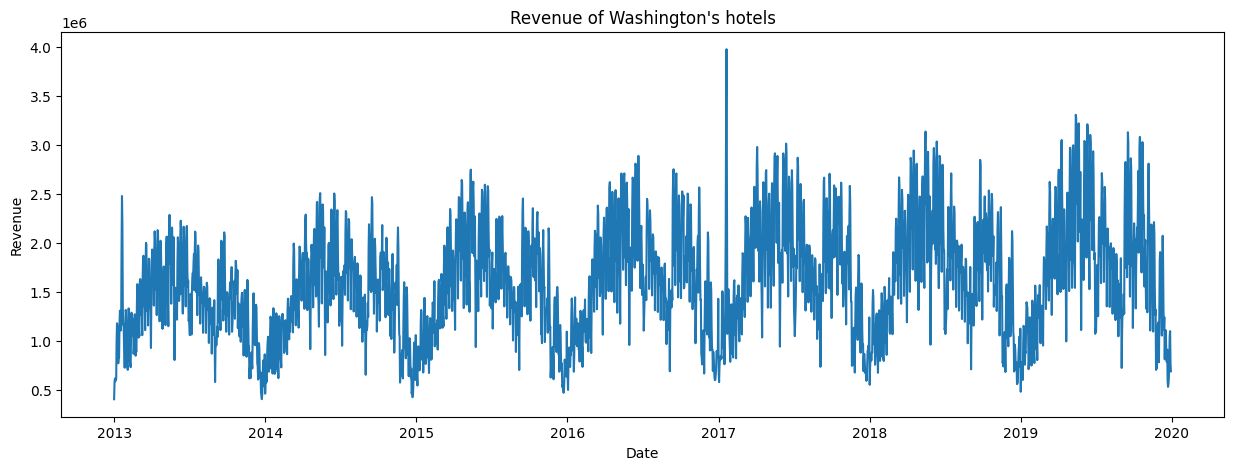

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(washington_df.Date, washington_df.Revenue)
plt.title("Revenue of Washington's hotels")
plt.xlabel("Date")
plt.ylabel("Revenue");

To remove such outliers, we implemented a rolling window approach which takes a few (30) samples and removes values outside of the +- 2.5 standard deviations.

In [ ]:
def get_outliers():
    window_size = 30

    rolling_mean = washington_df.Revenue.rolling(window=window_size, center=True).mean()

    rolling_std = washington_df.Revenue.rolling(window=window_size, center=True).std()

    mult = 2.5
    upper_bound = rolling_mean + mult * rolling_std
    lower_bound = rolling_mean - mult * rolling_std

    outliers = (washington_df.Revenue > upper_bound) | (washington_df.Revenue < lower_bound)
    return outliers

outliers = get_outliers()
df_filtered = washington_df[~outliers]
print("Number of outliers removed: ", washington_df.shape[0] - outliers.value_counts()[0])

Number of outliers removed:  5


To understand the effects of outliers removal, below the plots of before/after their removal

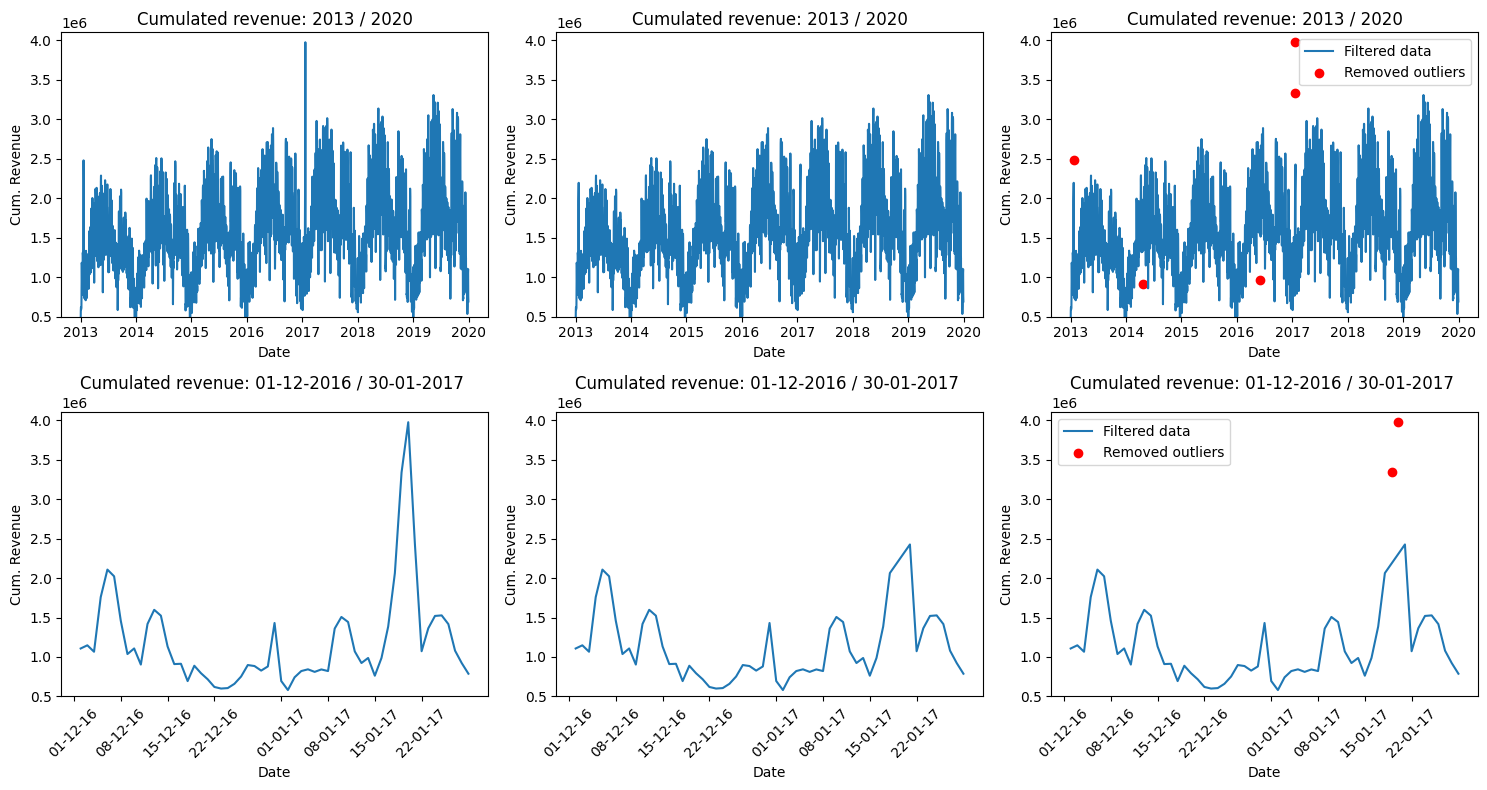

In [ ]:
fig, ax = plt.subplots(ncols=3, nrows=2, figsize=(15, 8))
ax[0, 0].plot(washington_df.Date, washington_df.Revenue)
ax[0, 1].plot(df_filtered.Date, df_filtered.Revenue)
ax[0, 2].plot(df_filtered.Date, df_filtered.Revenue, label="Filtered data")
ax[0, 2].scatter(washington_df[outliers].Date, washington_df[outliers].Revenue, color="red", label="Removed outliers")
ax[0, 2].legend()

start_date, end_date, date_format = '2016-12-01', '2017-01-30', '%d-%m-%y'
temp_df = washington_df[(washington_df.Date > start_date) & (washington_df.Date < end_date)]
temp_df_filtered = df_filtered[(df_filtered.Date > start_date) & (df_filtered.Date < end_date)]

ax[1, 0].plot(temp_df.Date, temp_df.Revenue)
ax[1, 1].plot(temp_df_filtered.Date, temp_df_filtered.Revenue)
ax[1, 2].plot(temp_df_filtered.Date, temp_df_filtered.Revenue, label="Filtered data")
ax[1, 2].scatter(temp_df[outliers].Date, temp_df[outliers].Revenue, color="red", label="Removed outliers")
ax[1, 2].legend()


for i in range(3):
    ax[0, i].set_xlabel('Date')
    ax[0, i].set_ylabel('Cum. Revenue')
    ax[0, i].set_title(f'Cumulated revenue: 2013 / 2020')
    ax[0, i].set_ylim([0.5e6, 4.1e6])

    ax[1, i].set_xlabel('Date')
    ax[1, i].set_ylabel('Cum. Revenue')
    ax[1, i].set_title(f'Cumulated revenue: {"-".join(start_date.split("-")[::-1])} / {"-".join(end_date.split("-")[::-1])} ')
    ax[1, i].xaxis.set_major_formatter(mdates.DateFormatter(date_format))
    ax[1, i].tick_params(axis='x', rotation=45)
    ax[1, i].set_ylim([0.5e6, 4.1e6])


plt.tight_layout()
plt.show()

To understand the severity of the seasonality, the boxplots of the daily/monthly distributions were plotted, which show a clear tendency of some days/months to be much more profitable than others.

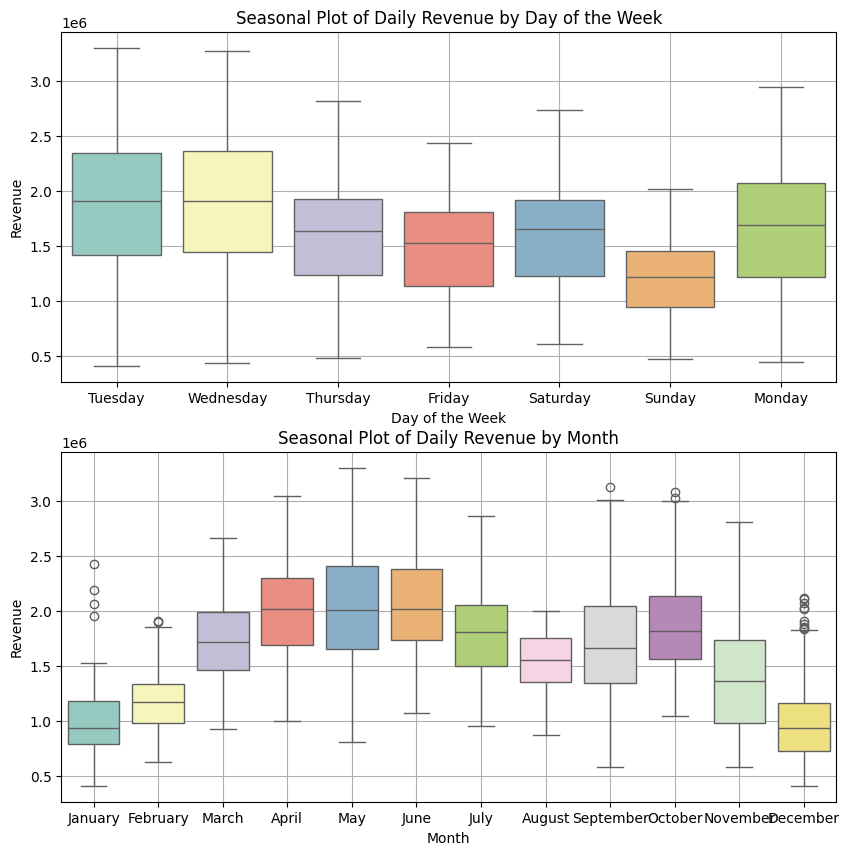

In [ ]:

fig, ax = plt.subplots(nrows=2, figsize=(10, 10))
df_filtered['DayOfWeek'] = df_filtered['Date'].dt.day_name()
df_filtered['Month'] = df_filtered['Date'].dt.month_name()

sns.boxplot(x='DayOfWeek', y='Revenue', data=df_filtered, palette='Set3', ax=ax[0])
ax[0].set_title('Seasonal Plot of Daily Revenue by Day of the Week')
ax[0].set_xlabel('Day of the Week')
ax[0].set_ylabel('Revenue')
ax[0].grid(True)

sns.boxplot(x='Month', y='Revenue', data=df_filtered, palette='Set3', ax=ax[1])
ax[1].set_title('Seasonal Plot of Daily Revenue by Month')
ax[1].set_xlabel('Month')
ax[1].set_ylabel('Revenue')
ax[1].grid(True)

Given the columns we wanted to see if there was any correlation, which there was as expexcted given the columns we have (Demand, Occupancy, Revenue)

<Axes: >

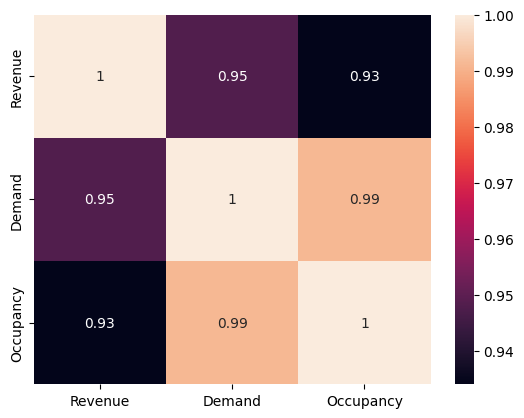

In [ ]:
corr = df_filtered[["Revenue", "Demand", "Occupancy"]].corr()
sns.heatmap(corr, annot=True)

Below the plot of the aforementioned columns. As we can see, the demand and occupancy columns are practically identical, and they follow the same seasonality and trend of the Revenue one.

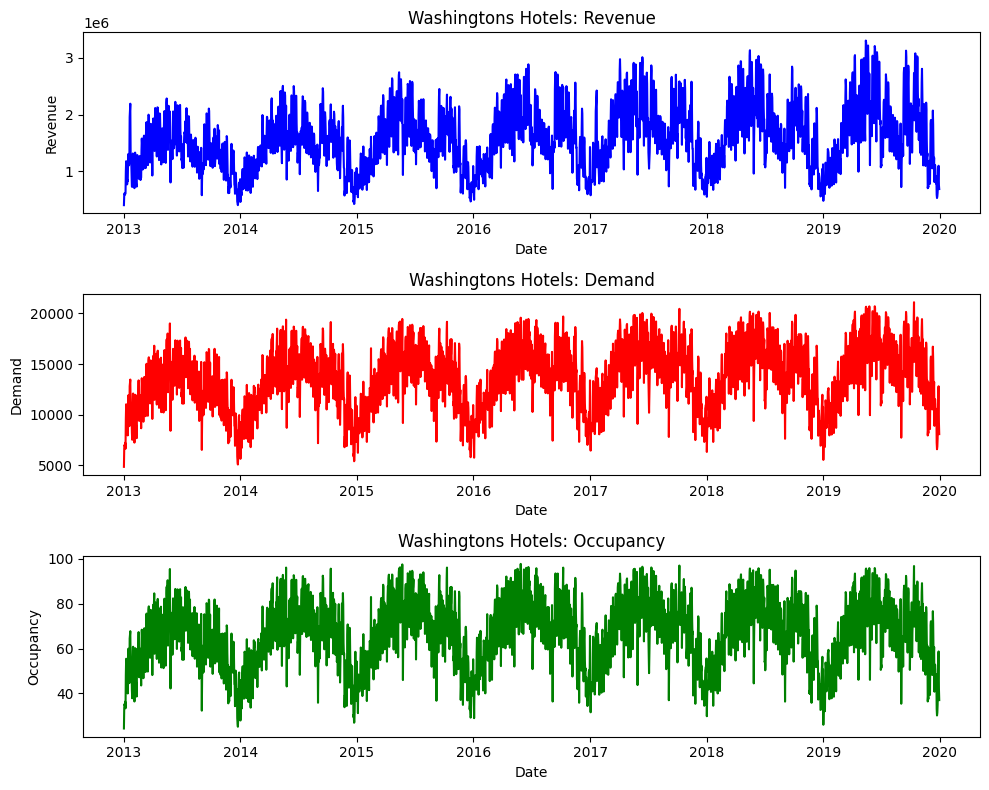

In [ ]:
fig, ax = plt.subplots(nrows=3, figsize=(10, 8))
cols = ["Revenue", "Demand", "Occupancy"]
colors = ["blue", "red", "green"]
for i, col in enumerate(cols):
    ax[i].plot(df_filtered.Date, df_filtered[col], color=colors[i])
    ax[i].set_title(f"Washingtons Hotels: {col}")
    ax[i].set_xlabel("Date")
    ax[i].set_ylabel(col)

plt.tight_layout()
plt.show()

Apart from the classic data plotting, we wanted to perform some exploration that would give us more meaningful insights from an practical standpoint. By obtaining the Approximate Entropy, we were able to tell that there is some regularity in our data, but its not constant in time meaning that some patterns could slightly vary. This goes for all the 3 columns

In [ ]:
names = ["Revenue", "Demand", "Occupancy"]
entropies = []

for name in names:
    entropy = ApEn(df_filtered[name].values, m=7)[0][3]
    entropies.append(entropy)

df_entropy = pd.DataFrame(pd.Series(entropies))
df_entropy = df_entropy.T
df_entropy.columns = names
df_entropy

,Revenue,Demand,Occupancy
0,0.906558,0.903151,0.889448


By plotting the ACF (Auto Correlation Function) plots, we gained significant insights regarding seasonality and influence of past data on the new. These plots could suggest our future need of transformations of the data in order to make them stationary.

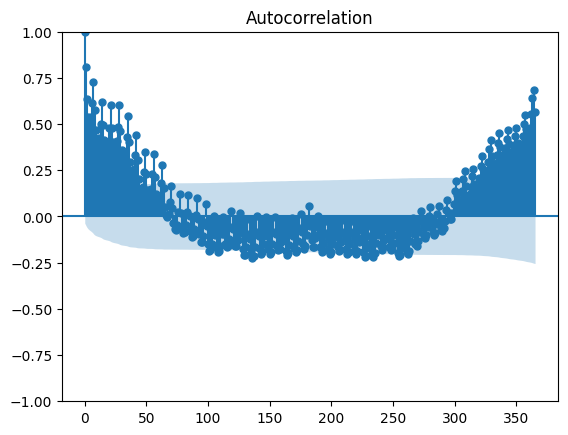

In [ ]:

time_series = df_filtered['Revenue']
plot_acf(time_series, lags=365)
plt.show()

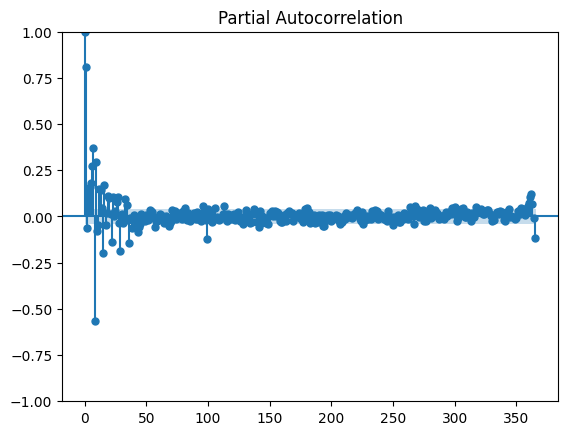

In [ ]:
time_series = df_filtered['Revenue']
plot_pacf(time_series, lags=365)
plt.show()

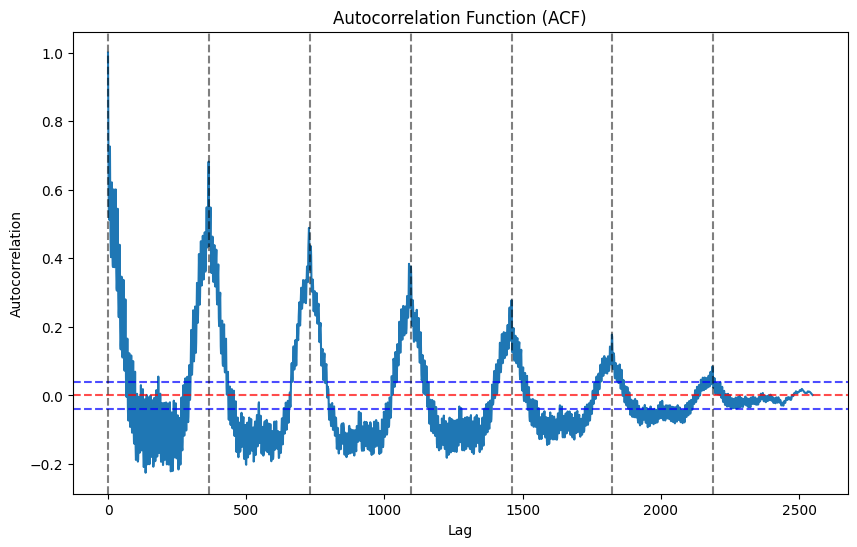

In [ ]:
rev = df_filtered.Revenue

acf_values = acf(rev, nlags=len(rev))

plt.figure(figsize=(10, 6))
plt.plot(acf_values)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)  # Add reference line at y=0
plt.axhline(y=1.96/np.sqrt(len(rev)), color='blue', linestyle='--', alpha=0.7)
plt.axhline(y=-1.96/np.sqrt(len(rev)), color='blue', linestyle='--', alpha=0.7)  # Confidence bounds
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function (ACF)')

for i in range(0, len(rev), 365):
    plt.axvline(x=i, color='black', linestyle='--', alpha=0.5)
plt.show()

# Model Building

Below the seasonality of our data can be furtherly confirmed by the seasonal decomposition, from which a clear pattern can be seen

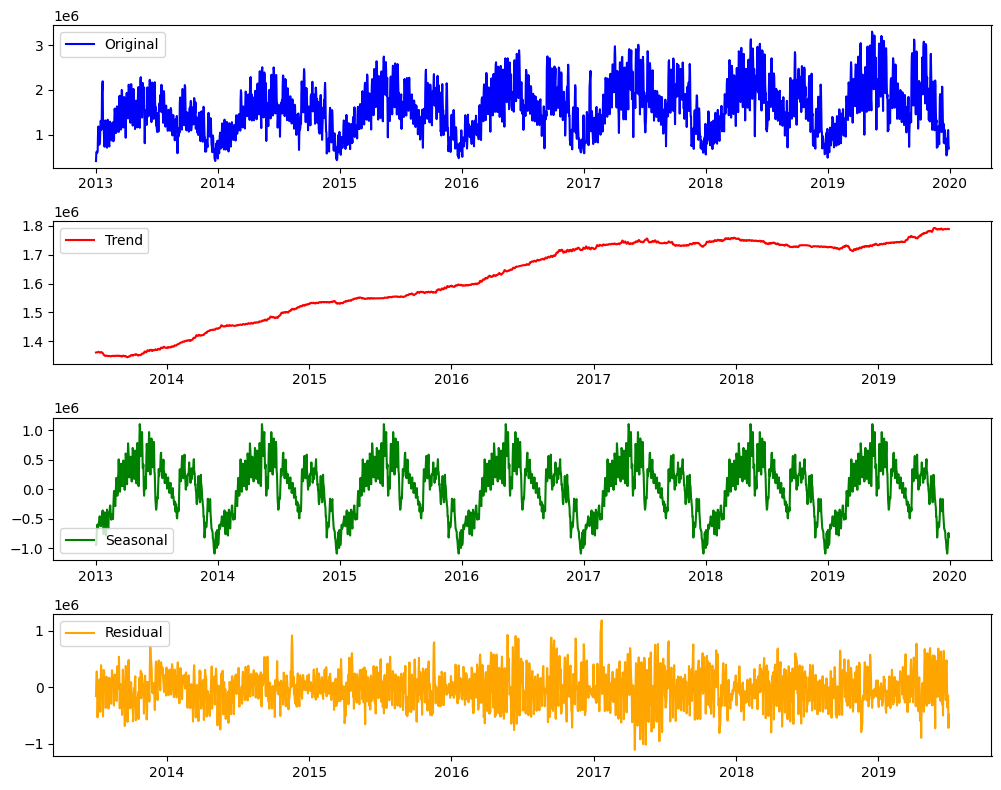

In [ ]:
decomposition = seasonal_decompose(df_filtered['Revenue'], model='additive', period=365)  # Assuming a seasonal period of 30 days
plt.figure(figsize=(10, 8))

plt.subplot(4, 1, 1)
plt.plot(df_filtered['Date'], df_filtered['Revenue'], label='Original', color='blue')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(df_filtered['Date'], decomposition.trend, label='Trend', color='red')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(df_filtered['Date'], decomposition.seasonal, label='Seasonal', color='green')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(df_filtered['Date'], decomposition.resid, label='Residual', color='orange')
plt.legend()

plt.tight_layout()
plt.show()


In order to compare future models and see if the models work better with seasonal or deseasonalized data, we decided to remove the seasonal component from the data, and the plot shows how does it look now.

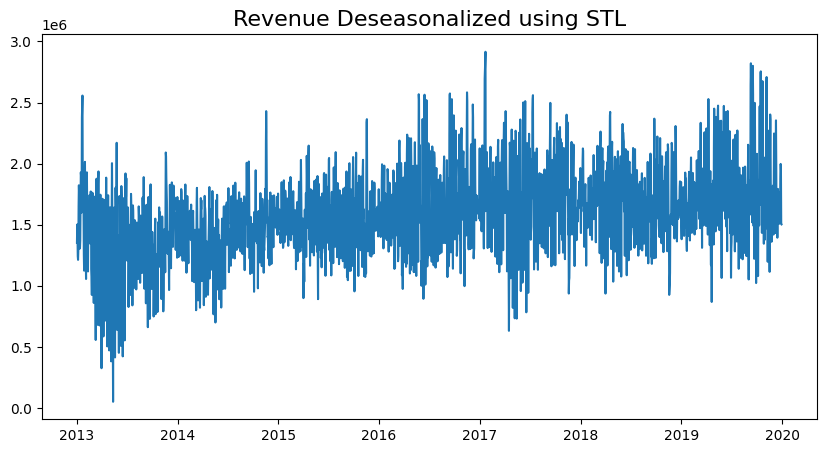

In [ ]:
deseasonalized_df = df_filtered.copy()
deseasonalized_df["Revenue"] -= decomposition.seasonal

plt.figure(figsize=(10, 5))
plt.plot(deseasonalized_df["Date"], deseasonalized_df["Revenue"])
plt.title('Revenue Deseasonalized using STL', fontsize=16)
plt.plot();

One approach we chose in order to make the data more stationary was to remove the yearly average from all the values of our time series.

In [ ]:
df_filtered["year"] = df_filtered["Date"].dt.year
mean_yearly = df_filtered.groupby("year")["Revenue"].mean()

detrended_yearly = df_filtered.copy()
detrended_yearly["Revenue"] = detrended_yearly["Revenue"] - detrended_yearly["year"].map(mean_yearly)

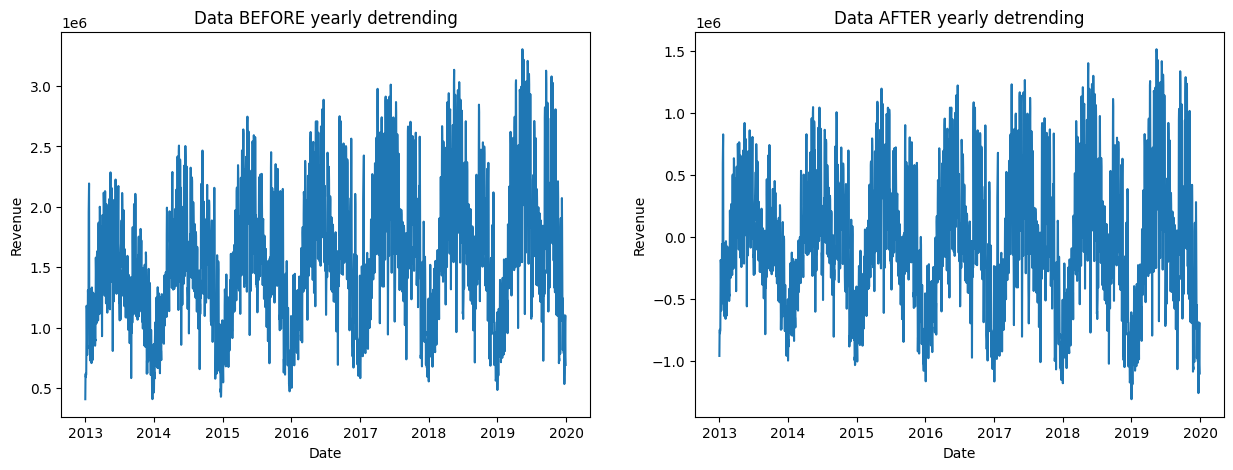

In [ ]:
fig, ax = plt.subplots(ncols=2, figsize=(15, 5))
ax[0].plot(df_filtered.Date, df_filtered.Revenue)
ax[0].set_title("Data BEFORE yearly detrending")
ax[0].set_xlabel("Date")
ax[0].set_ylabel("Revenue")

ax[1].plot(detrended_yearly.Date, detrended_yearly.Revenue)
ax[1].set_title("Data AFTER yearly detrending")
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Revenue");

Another detrending approach we were able to implement was the one provided by the scipy.signal library, where we specified a "linear" type of model being the fact that our trend resembles an increasing straight line. The results in comparison to the yearly detrending we implemented manually are almost identical.

Aside from the classic detrending, we performed a moving average detrending which removes both seasonal and trend components from our data, which we will use further on for one of the models


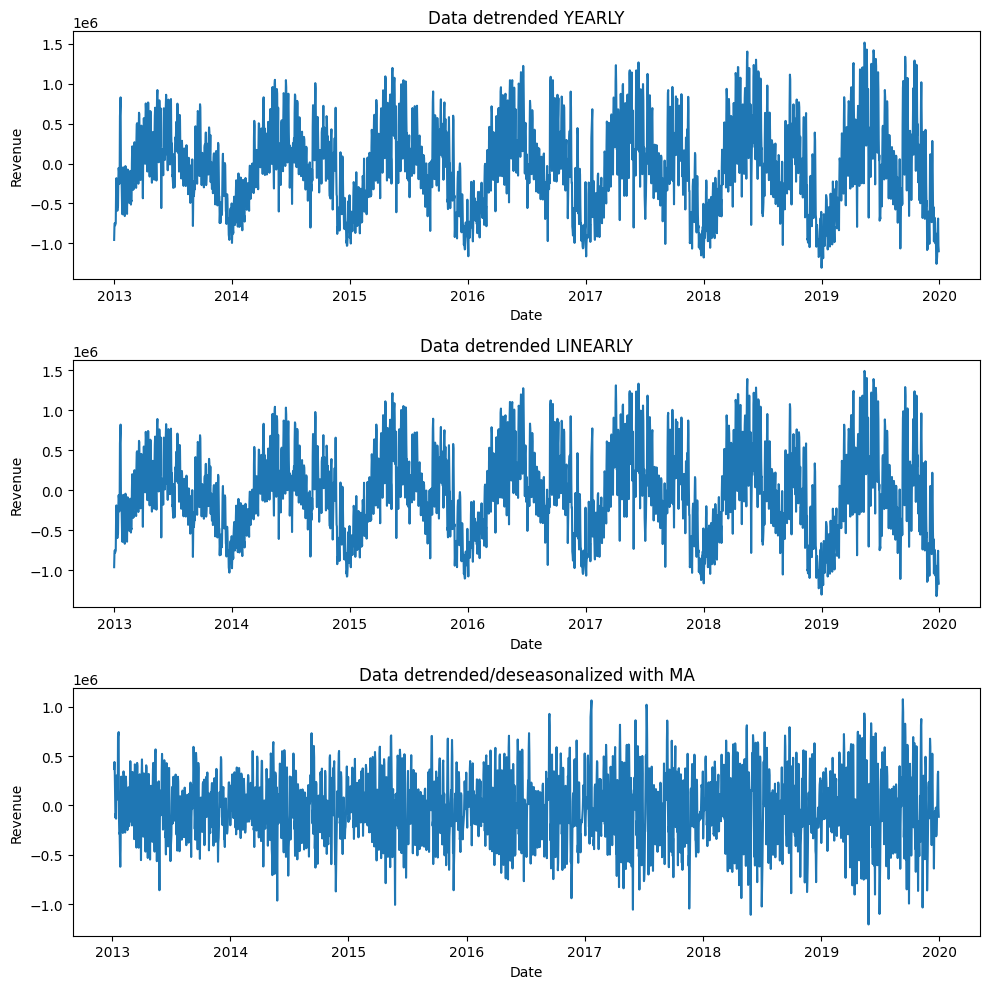

In [ ]:
detrended_scipy = detrend(df_filtered['Revenue'], type="linear")
detrended_scipy = pd.Series(detrended_scipy, index=df_filtered.index)
detrended_scipy_df = df_filtered.copy()
detrended_scipy_df["Revenue"] = detrended_scipy

rolling_average = lambda df, N: df['Revenue'].rolling(window=N).mean()
trend = rolling_average(df_filtered, 7)
detrended_mav = df_filtered.copy()
detrended_mav["Revenue"] -= trend
detrended_mav.dropna(inplace=True)


fig, ax = plt.subplots(nrows=3, figsize=(10, 10))
ax[0].plot(detrended_yearly.Date, detrended_yearly.Revenue)
ax[0].set_title("Data detrended YEARLY")
ax[0].set_xlabel("Date")
ax[0].set_ylabel("Revenue")

ax[1].plot(detrended_scipy_df.Date, detrended_scipy_df.Revenue)
ax[1].set_title("Data detrended LINEARLY")
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Revenue");

ax[2].plot(detrended_mav.Date, detrended_mav.Revenue)
ax[2].set_title("Data detrended/deseasonalized with MA")
ax[2].set_xlabel("Date")
ax[2].set_ylabel("Revenue");

plt.tight_layout()
plt.show()

To verify the presence of stationarity, we decided to perform two different tests: Dickey-Fuller and KPSS statistic. The results from there two tests remove out of the equation the stationarity of the raw data and the deseasonalized ones. About the various versions of detrended data, the two tests prove their stationarity. Starting from this, we can say that for modelling, only detrended data will be used and, depending on the specific task, either one version of detrending or another.

In [ ]:
def check_stationarity(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')

    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)
    print(f'Result: The series is {"not " if dftest[1] > 0.05 else ""}stationary')

def kpss_test(series, **kw):
    statistic, p_value, n_lags, critical_values = kpss(series, **kw)
    print(f'KPSS Statistic: {statistic}')
    print(f'p-value: {p_value}')
    print(f'num lags: {n_lags}')
    print('Critial Values:')
    for key, value in critical_values.items():
        print(f'   {key} : {value}')

    print(f'Result: The series is {"not " if p_value < 0.05 else ""}stationary')

In [ ]:
print("Check of stationarity: ORIGINAL\n")
check_stationarity(df_filtered.Revenue)
print('-'*30)
print("\nCheck of stationarity: DESEASONALIZED\n")
check_stationarity(deseasonalized_df.Revenue)
print('-'*30)
print("\nCheck of stationarity: YEALY DETRENDED\n")
check_stationarity(detrended_yearly.Revenue)
print('-'*30)
print("\nCheck of stationarity: LINEARLY DETRENDED\n")
check_stationarity(detrended_scipy_df.Revenue)
print('-'*30)
print("\nCheck of stationarity: MAV DETRENDED\n")
check_stationarity(detrended_mav.Revenue)

Check of stationarity: ORIGINAL

Results of Dickey-Fuller Test:
Test Statistic                   -3.252582
p-value                           0.017136
#Lags Used                       27.000000
Number of Observations Used    2522.000000
Critical Value (1%)              -3.432946
Critical Value (5%)              -2.862687
Critical Value (10%)             -2.567380
dtype: float64
Result: The series is stationary
------------------------------

Check of stationarity: DESEASONALIZED

Results of Dickey-Fuller Test:
Test Statistic                   -2.835244
p-value                           0.053413
#Lags Used                       27.000000
Number of Observations Used    2522.000000
Critical Value (1%)              -3.432946
Critical Value (5%)              -2.862687
Critical Value (10%)             -2.567380
dtype: float64
Result: The series is not stationary
------------------------------

Check of stationarity: YEALY DETRENDED

Results of Dickey-Fuller Test:
Test Statistic               

In [ ]:
print("Check of stationarity: ORIGINAL\n")
kpss_test(df_filtered.Revenue)
print('-'*30)
print("\nCheck of stationarity: DESEASONALIZED\n")
kpss_test(deseasonalized_df.Revenue)
print('-'*30)
print("\nCheck of stationarity: YEALY DETRENDED\n")
kpss_test(detrended_yearly.Revenue)
print('-'*30)
print("\nCheck of stationarity: LINEARLY DETRENDED\n")
kpss_test(detrended_scipy_df.Revenue)
print('-'*30)
print("\nCheck of stationarity: MAV DETRENDED\n")
kpss_test(detrended_mav.Revenue)

Check of stationarity: ORIGINAL

KPSS Statistic: 1.1424236288610563
p-value: 0.01
num lags: 27
Critial Values:
   10% : 0.347
   5% : 0.463
   2.5% : 0.574
   1% : 0.739
Result: The series is not stationary
------------------------------

Check of stationarity: DESEASONALIZED

KPSS Statistic: 9.704730057520068
p-value: 0.01
num lags: 17
Critial Values:
   10% : 0.347
   5% : 0.463
   2.5% : 0.574
   1% : 0.739
Result: The series is not stationary
------------------------------

Check of stationarity: YEALY DETRENDED

KPSS Statistic: 0.03536457487339616
p-value: 0.1
num lags: 27
Critial Values:
   10% : 0.347
   5% : 0.463
   2.5% : 0.574
   1% : 0.739
Result: The series is stationary
------------------------------

Check of stationarity: LINEARLY DETRENDED

KPSS Statistic: 0.05480184694923858
p-value: 0.1
num lags: 27
Critial Values:
   10% : 0.347
   5% : 0.463
   2.5% : 0.574
   1% : 0.739
Result: The series is stationary
------------------------------

Check of stationarity: MAV DET

## Model Selection and CV

This function will be used within the rest of the notebook to evaluate the perfomances of our models. It computes the Normalized Mean Absolute Error between the predictions and true values passed as parameters

In [ ]:
def horizon_error_calculation(pred, y_test):
    horizon_errors = []
    for i in range(7):
        mean_abs_error = np.mean(np.abs(pred[:, i] - y_test[:, i]))
        norm_factor = np.mean(y_test[:, i])
        nmae = mean_abs_error / norm_factor
        horizon_errors.append(nmae)
    return horizon_errors

The way we want to predict the data and evaluate them is by predicting all the instances in our dataframe where we can take the previous X days and use them to forecast the next Y days.

For this reason, we implemented this function which takes a series as input and the sizes of X windows and Y windows, and goes through the dataframe in order to build two lists containing:
- lists of days used to predict, with each list being the shifted version of the previous by 1 day
- lists of days being predicted, with each list being the shifted version of the previous by 1 day


In [ ]:
def xy_to_reshape(series, window_x, window_y):

    total_data_points = len(series) - window_x + 1

    x_data = []
    y_data = []

    for i in range(total_data_points):
        x = series[i:i+window_x]
        y = series[i+window_x:i+window_x+window_y]

        if len(x) == window_x and len(y) == window_y:
            x_data.append(x)
            y_data.append(y)

    return np.array(x_data).astype(np.float32), np.array(y_data).astype(np.float32)

This function instead takes as input X and Y in the format we were aiming for with the previous function xy_to_reshape, and returns the list of predictions for each combination of the 7 days ahead in time.

In [ ]:
def model_predict(x, y):
    predictions = []
    for i in range(y.shape[0]):
        model = ARIMA(x[i, :], order=(2, 1, 1))
        pred = model.fit().forecast(steps=y.shape[1])
        predictions.append(pred)

        print(f"Progress: {i}/{y.shape[0]}", end="\r")

    return np.array(predictions)

For future modelling and also horizon optimization, we define the train and test splits of the Revenue column, respectively 80% and 20%

In [ ]:
train = detrended_yearly.Revenue.iloc[:int(len(detrended_yearly)*0.8)].values
test = detrended_yearly.Revenue.iloc[int(len(detrended_yearly)*0.8):].values
test = pd.Series(test)
train = pd.Series(train)

print(train.shape, test.shape)

(2040,) (510,)


As part of model preprocessing, we decided to rescale the data in order to have comparable metrics which are objective to a certain scale, and also because for some of the models its actually better to have data rescaled

In [ ]:
scaler = MinMaxScaler()
train = scaler.fit_transform(train.values.reshape(-1, 1)).flatten()
test = scaler.transform(test.values.reshape(-1, 1)).flatten()

print(train.shape, test.shape)

(2040,) (510,)


### History optimization

In order to predict the future days, we need to define how many days we should use such that our performances would be optimal in terms of accuracy of our predictions and time taken to train the models.
At first we implemented this optimization using a simple Arima model, which would give us an indication of how good different horizons were in terms of performances. This gave us a starting point from which to fit our next models, and once we found the best one, we decided to use it to furtherly optimize the history parameter, making our analysis even more reliable

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
        patience=5,
        min_delta=0.001,
        restore_best_weights=True
    )

def lstm_trainer(x_train, y_train, epochs=20, batch_size=64, history=40, pred_horizon=7):

    optimizer = Adam(learning_rate=0.001)

    model = keras.Sequential()
    model.add(LSTM(units=32, return_sequences=False, activation='tanh', input_shape=(history, 1)))
    model.add(keras.layers.Dense(pred_horizon, activation='linear'))

    model.compile(loss="mean_absolute_error", optimizer=optimizer)

    x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))

    history = model.fit(x_train, y_train, batch_size=batch_size, epochs=20, validation_split=0.2, callbacks=[early_stopping], shuffle=True, verbose=0)

    return model

In [ ]:
condition = True
history = 365
n_max_samples = 100

results = []

while condition:
    x_train, y_train = xy_to_reshape(train, history, 7)
    x_test, y_test = xy_to_reshape(test, history, 7)

    if x_train.shape[0] > n_max_samples:
        indexes = np.random.choice(x_train.shape[0], n_max_samples, replace=False)
        x_train = x_train[indexes]
        y_train = y_train[indexes]

    print(x_train.shape, y_train.shape)

    x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))

    model = lstm_trainer(x_train, y_train, history=history)
    preds = model.predict(x_train.reshape((x_train.shape[0], x_train.shape[1], 1)))

    horizon_errors = horizon_error_calculation(preds, y_train)

    print(history, horizon_errors)
    results.append([horizon_errors, history])

    history = history / 100 * 60
    history = int(history)

    if history < 5:
        condition = False

(100, 365) (100, 7)


4/4 [==============================] - 0s 20ms/step
365 [0.3003631, 0.25635472, 0.26274812, 0.28698108, 0.30426154, 0.29811227, 0.29405484]
(100, 219) (100, 7)
4/4 [==============================] - 0s 13ms/step
219 [0.27867413, 0.24179304, 0.29802704, 0.2694302, 0.35650936, 0.3096869, 0.3134621]
(100, 131) (100, 7)
4/4 [==============================] - 0s 8ms/step
131 [0.23490347, 0.2652023, 0.30091518, 0.28355408, 0.33901653, 0.24598429, 0.3073569]
(100, 78) (100, 7)
4/4 [==============================] - 0s 5ms/step
78 [0.23477966, 0.2507987, 0.24867731, 0.2845047, 0.24219069, 0.2592389, 0.30753028]
(100, 46) (100, 7)
4/4 [==============================] - 0s 5ms/step
46 [0.2768226, 0.5107623, 0.5431712, 0.2810456, 0.27387843, 0.29858357, 0.2879794]
(100, 27) (100, 7)
4/4 [==============================] - 0s 3ms/step
27 [0.25797665, 0.32331046, 0.29846683, 0.25689724, 0.24988882, 0.2486914, 0.3533439]
(100, 16) (100, 7)
4/4 [==============================] - 0s 0s/step
16 [0.29560

9


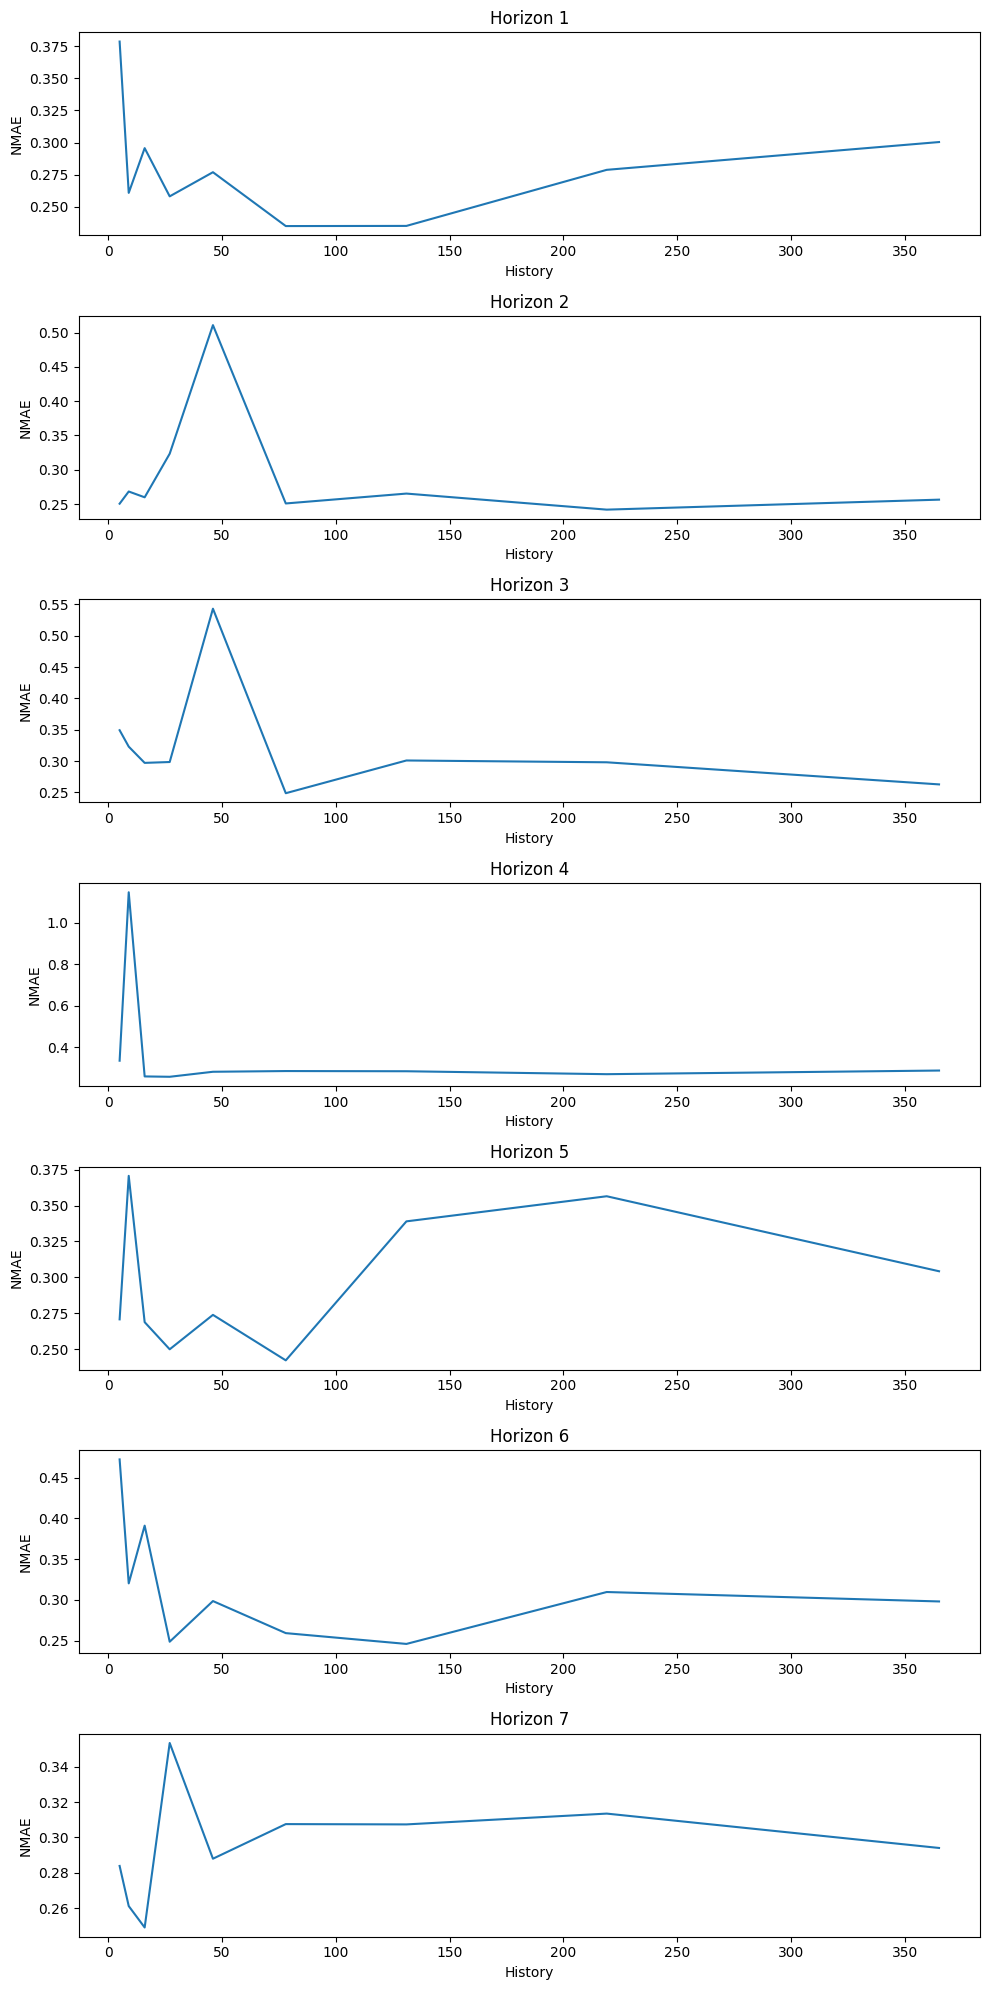

In [ ]:
errors = [x[0] for x in results]
print(len(errors))

fig, ax = plt.subplots(nrows=7, figsize=(10, 20))

for i in range(7):
    ax[i].plot([x[1] for x in results], [x[i] for x in errors])
    ax[i].set_title(f"Horizon {i+1}")
    ax[i].set_xlabel("History")
    ax[i].set_ylabel("NMAE")

plt.tight_layout()
plt.show()

As can be seen from the plots above representing the NMAE (Normalized Mean Absolute Error) of all the separate 7 days. After the analysis of the errors and the overall performances, it can be concluded that lower values of history for 7 days ahead predictions are preferred to big quantities

In [ ]:
min_error = np.inf
best_hist = 0
for i in results:
    mean_error = np.mean(i[0])
    hist = i[1]

    if mean_error < min_error:
        min_error = mean_error
        best_hist = hist

print(f"Best history: {best_hist}, with an average error of {min_error}")
history = int(best_hist)

Best history: 78, with an average error of 0.2611028850078583


### Train-Test Split

To correctly split the data in the desired way, we take advantage of the afore implemented xy_to_reshape function, giving to it the two lists train and test, the history parameter we previously retrieved, and the desired prediction horizon.

In [ ]:
pred_horizon = 7

x_train, y_train = xy_to_reshape(train, history, pred_horizon)
x_test, y_test = xy_to_reshape(test, history, pred_horizon)

print(x_test.shape, y_test.shape)
print(x_train.shape, y_train.shape)

(426, 78) (426, 7)
(1956, 78) (1956, 7)


Here we evaluate the first model which is a simple Arima with low parameters of p, q and d. We didn’t use the seasonal version of the Arima family of models because of computational limitations of such model given our seasonality being very high (365 days).

In [ ]:
arima_pred = model_predict(x_test, y_test)
arima_nmae = horizon_error_calculation(arima_pred, y_test)
arima_nmae

[0.2536613723142107,
 0.3395384436857175,
 0.36698792220197574,
 0.3738382182513133,
 0.37396702822328454,
 0.37408541924835464,
 0.36842000232714156]


For the 7 days predicted we get an NMAE which goes from approximately 0.3 to 0.4, which is a pretty poor performance. We expect better from the next models


Below you find a function useful for benchmark evaluation of our dataset

In [ ]:
def cast_df(y, df):
    h = len(y)
    return pd.DataFrame(y, index=np.arange(len(df), len(df)+h))

As for the benchmark models we used the Naive, Mean and Seasonal models, for which NMAE scores were computed and their average performances are between 0.35 and 0.44. All the 3 models are good indicators of the previously discovered bad performance of the basic Arima implementation

In [ ]:
p=7
naive = lambda x, h: cast_df(np.tile(x.iloc[-1], h), x)
mean = lambda x, h: cast_df(np.tile(x.mean(), h), x)
seasonal = lambda x, h: cast_df(np.tile(x.iloc[-p:].values.ravel() -x.iloc[-p:].values[0]+x.iloc[-p:].values[-1],
                                        int(np.ceil(h/p)))[:h], x)

naive_preds = []
mean_preds = []
seasonal_preds = []

for i in range(x_test.shape[0]):
    naive_pred = naive(pd.Series(x_test[i, :]), pred_horizon)
    mean_pred = mean(pd.Series(x_test[i, :]), pred_horizon)
    seasonal_pred = seasonal(pd.Series(x_test[i, :]), pred_horizon)

    naive_preds.append(naive_pred)
    mean_preds.append(mean_pred)
    seasonal_preds.append(seasonal_pred)

In [ ]:
naive_preds = np.array(naive_preds)
naive_preds = naive_preds.reshape(naive_preds.shape[0], naive_preds.shape[1])
mean_preds = np.array(mean_preds)
mean_preds = mean_preds.reshape(mean_preds.shape[0], mean_preds.shape[1])
seasonal_preds = np.array(seasonal_preds)
seasonal_preds = seasonal_preds.reshape(seasonal_preds.shape[0], seasonal_preds.shape[1])

In [ ]:
nmae_naive = horizon_error_calculation(naive_preds, y_test)
nmae_mean = horizon_error_calculation(mean_preds, y_test)
nmae_seasonal = horizon_error_calculation(seasonal_preds, y_test)

print(np.mean(nmae_naive), np.mean(nmae_mean), np.mean(nmae_seasonal))

0.39739034 0.45726568 0.45374793


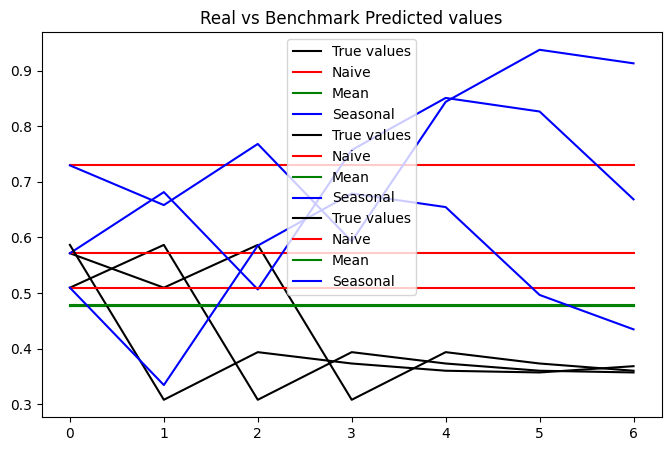

In [ ]:
plt.figure(figsize=(8, 5))
plt.title("Real vs Benchmark Predicted values")
for i in range(3):
    plt.plot(y_test[i, :], label='True values', color='black')
    plt.plot(naive_preds[i, :], label='Naive', color='red')
    plt.plot(mean_preds[i, :], label='Mean', color='green')
    plt.plot(seasonal_preds[i, :], label='Seasonal', color='blue')
plt.legend()

## Auto-arima

We also implemented an AutoArima model which would hopefully give us the optimal parameters for our specific task, but the problem with it (as is with the SARIMA variant) is the size of the dataset and the seasonality parameter, which both contribute to extremely large computational times, which we couldn't provide.

For these reasons, we just gave a little portion of the data with a low seasonality parameter of 30

In [ ]:
temp = test[:60]
model = auto_arima(temp, seasonal=True, m=30, stepwise=True, suppress_warnings= True, n_jobs=-1)

In [ ]:
arima_preds = []
for i in range(x_test.shape[0]):
    model.fit(x_test[i, :])
    arima_pred = model.predict(pred_horizon)
    arima_preds.append(arima_pred)

In [ ]:
arima_preds = np.array(arima_preds)

The results provided by this model are even worse than the classic Arima approach. Maybe with other circumstances it could've been trained better, but this was not the case for our dataset

In [ ]:
auto_arima_rmse = horizon_error_calculation(arima_preds, y_test)
auto_arima_rmse

[0.2643235396785991,
 0.34763031944109507,
 0.36455959952628514,
 0.3714313333630097,
 0.35868678942864557,
 0.3599741867441379,
 0.354858125054728]

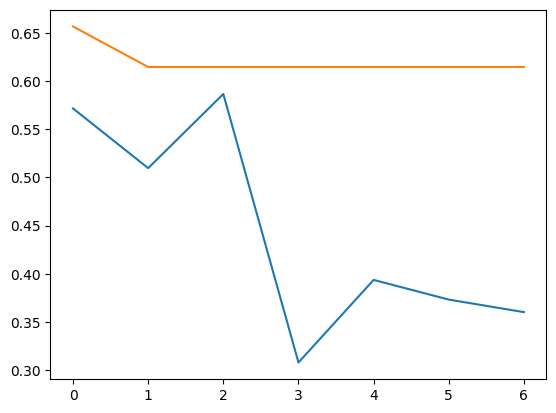

In [ ]:
plt.plot(y_test[0, :], label="Actual")
plt.plot(arima_preds[0, :], label="AutoARIMA")

## VAR (Vector AutoRegression)

Vector Autoregression is a statistical model that captures the linear interdependencies among multiple time series by using the system’s history to predict future values of each variable, making it highly useful for forecasting scenarios where multiple interrelated variables influence each other over time.

In [ ]:
data_var = detrended_yearly[['Date', 'Revenue', 'Demand', 'Occupancy']].copy()

date_col = data_var['Date']

data_var.reset_index(inplace=True, drop=True)
data_var.drop(columns=['Date'], inplace=True)

Before we were dealing with just a series, but in this case we need the other features, therefore a scaling of the entire dataframe is needed before proceeding next

In [ ]:
data_var_scaled = scaler.fit_transform(data_var)
data_var_scaled = pd.DataFrame(data_var_scaled, columns=data_var.columns)
data_var_scaled['Date'] = date_col.values
data_var_scaled

,Revenue,Demand,Occupancy,Date
0,0.123679,0.000000,0.000000,2013-01-01
1,0.185676,0.112457,0.125405,2013-01-02
2,0.198526,0.133388,0.148746,2013-01-03
3,0.188329,0.124533,0.138871,2013-01-04
4,0.195145,0.146331,0.163178,2013-01-05
...,...,...,...,...
2545,0.131258,0.333776,0.309822,2019-12-26
2546,0.200066,0.461155,0.439300,2019-12-27
2547,0.218721,0.489462,0.468074,2019-12-28
2548,0.098181,0.269067,0.244046,2019-12-29


By fitting the model, it automatically gives us the supposedly optimal value of the lag to use for prediction

In [ ]:
from statsmodels.tsa.vector_ar.var_model import VAR
train_var, test_var = data_var_scaled.iloc[:int(data_var_scaled.shape[0]*0.8)], data_var_scaled.iloc[int(data_var_scaled.shape[0]*0.8):]

train_var.set_index('Date', inplace=True)
model = VAR(train_var)
model_fitted = model.fit(maxlags=50, ic='aic')
best_lag = model_fitted.k_ar
best_lag

37

In [ ]:
DAYS_AHEAD = 7
y_true, y_pred = [], []
for i in range(test_var.shape[0]-DAYS_AHEAD):
    x_i = test_var.iloc[i:best_lag+i].set_index('Date')
    y_i = test_var.iloc[best_lag+i:best_lag+i+DAYS_AHEAD]

    if x_i.shape[0] == best_lag and y_i.shape[0] == DAYS_AHEAD:
        y_true.append(y_i.Revenue.values)
        forecast = model_fitted.forecast(x_i.values, steps=DAYS_AHEAD)
        forecast_df = pd.DataFrame(forecast, columns=train_var.columns)
        y_pred.append(forecast_df.Revenue.values)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
var_nmae = horizon_error_calculation(y_pred, y_true)
np.mean(var_nmae)

0.2163557304800578

## LSTM

Since we are dealing with sequential data, LSTM models are known to tackle well this kind of problem, maintaining context from previously seen data and leverage it for future predictions

In [ ]:
print(x_train.shape, y_train.shape)
x_train = np.array(x_train)
y_train = np.array(y_train)
print(x_train.shape, y_train.shape)

(1956, 78) (1956, 7)
(1956, 78) (1956, 7)


In [ ]:
batch_size = 16
lstm_learning_rate = 0.001

This function receives the data, the number of epochs / batch size, and the horizon values for both days used to predict and days to predict, and returns a trained LSTM model. This function will also be used later on for cross validation

In [ ]:
def lstm_trainer(x_train, y_train, epochs=200, batch_size=64, history=best_hist, pred_horizon=7):

    early_stopping = keras.callbacks.EarlyStopping(
        patience=10,
        min_delta=0.001,
        restore_best_weights=True
    )

    optimizer = Adam(learning_rate=lstm_learning_rate)

    model = keras.Sequential()
    model.add(LSTM(units=64, return_sequences=True, activation='tanh', input_shape=(history, 1)))
    model.add(LSTM(units=32, return_sequences=False, activation='tanh'))
    model.add(keras.layers.Dense(pred_horizon, activation='linear'))

    model.compile(loss="mean_absolute_error", optimizer=optimizer)

    x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))

    history = model.fit(x_train, y_train, batch_size=batch_size, epochs=200, validation_split=0.2, callbacks=[early_stopping], shuffle=True, verbose=0)

    return model

In [ ]:
history = best_hist

early_stopping = keras.callbacks.EarlyStopping(
    patience=5,
    min_delta=0.001,
    restore_best_weights=True
)

optimizer = Adam(learning_rate= 0.001)

model = keras.Sequential()
model.add(LSTM(units=256, return_sequences=True, activation='tanh', input_shape=(history, 1)))
model.add(LSTM(units=32, return_sequences=False, activation='tanh'))
model.add(keras.layers.Dense(pred_horizon, activation='linear'))

model.compile(loss="mean_absolute_error", optimizer=optimizer)

x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))

history = model.fit(x_train, y_train, batch_size=batch_size, epochs=200, validation_split=0.2, callbacks=[early_stopping], shuffle=True)

Epoch 1/200
 1/98 [..............................] - ETA: 4:51 - loss: 0.5006

98/98 [==============================] - 12s 91ms/step - loss: 0.1375 - val_loss: 0.1391
Epoch 2/200
98/98 [==============================] - 9s 88ms/step - loss: 0.1190 - val_loss: 0.1349
Epoch 3/200
98/98 [==============================] - 8s 87ms/step - loss: 0.1166 - val_loss: 0.1326
Epoch 4/200
98/98 [==============================] - 8s 84ms/step - loss: 0.1144 - val_loss: 0.1328
Epoch 5/200
98/98 [==============================] - 8s 85ms/step - loss: 0.1120 - val_loss: 0.1260
Epoch 6/200
98/98 [==============================] - 9s 88ms/step - loss: 0.1075 - val_loss: 0.1227
Epoch 7/200
98/98 [==============================] - 9s 87ms/step - loss: 0.1031 - val_loss: 0.1246
Epoch 8/200
98/98 [==============================] - 8s 81ms/step - loss: 0.1010 - val_loss: 0.1155
Epoch 9/200
98/98 [==============================] - 8s 81ms/step - loss: 0.0997 - val_loss: 0.1088
Epoch 10/200
98/98 [==============================] - 8s 81ms/step - loss: 0.0960 - val_loss: 0.1148
Epoch 11/2

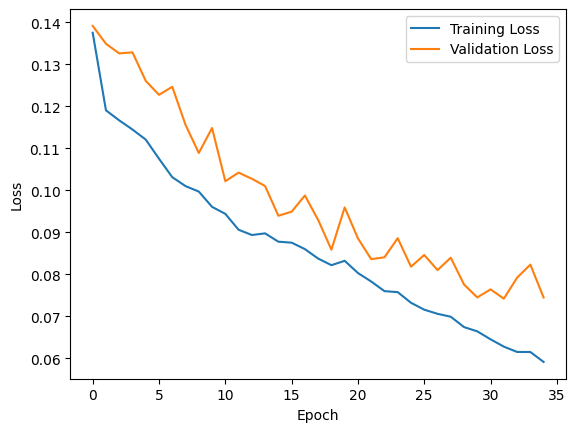

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

From the loss plot we can observe the model constantly learning up to the 40 epochs, after which it reaches a plateau and stops training thanks to the EarlyStopping mechanism of the neural network. There is a slight gap between Validation and Training loss, but given that the difference is minimal, we could overlook it

In [ ]:
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
pred = model.predict(x_test)

 1/14 [=>............................] - ETA: 8s

14/14 [==============================] - 1s 62ms/step


The average performance of the LSTM model is better than the Arima one, but still there is room for improvement

In [ ]:
k_nmae = horizon_error_calculation(pred, y_test)
print(np.mean(k_nmae))

0.2227069


## LSTM Splitted

For this model we took a different approach. If previously we were predicting directly the detrended signal itself, now we split the task in two: first forecasting the signal which was obtained by detrending with removal of the moving average, then we predict the moving average itself as a standalone signal, and for the final prediction we combine the two and compare the results.

The preprocessing we were applying before is also applied here, separately for the two distinct signals.

In [ ]:
nan_indexes = trend.index[trend.isna()].tolist()
detrended_mav = detrended_mav[~detrended_mav.index.isin(nan_indexes)]

trend = trend.dropna()
print(detrended_mav.shape, trend.shape)

(2544, 7) (2544,)


In [ ]:
ma = detrended_mav.Revenue
ma_train = ma.iloc[:int(len(ma)*0.8)].values
ma_test = ma.iloc[int(len(ma)*0.8):].values

trend_train = trend.iloc[:int(len(trend)*0.8)].values
trend_test = trend.iloc[int(len(trend)*0.8):].values

print(ma_train.shape, ma_test.shape)
print(trend_train.shape, trend_test.shape)

(2035,) (509,)
(2035,) (509,)


In [ ]:
scaler = MinMaxScaler()
ma_train = scaler.fit_transform(ma_train.reshape(-1, 1)).flatten()
ma_test = scaler.transform(ma_test.reshape(-1, 1)).flatten()

scaler = MinMaxScaler()
trend_train = scaler.fit_transform(trend_train.reshape(-1, 1)).flatten()
trend_test = scaler.transform(trend_test.reshape(-1, 1)).flatten()

print(ma_train.shape, ma_test.shape)
print(trend_train.shape, trend_test.shape)

(2035,) (509,)
(2035,) (509,)


In [ ]:
history = best_hist

In [ ]:
x_train_ma, y_train_ma = xy_to_reshape(ma_train, history, pred_horizon)
x_test_ma, y_test_ma = xy_to_reshape(ma_test, history, pred_horizon)

x_train_trend, y_train_trend = xy_to_reshape(trend_train, history, pred_horizon)
x_test_trend, y_test_trend = xy_to_reshape(trend_test, history, pred_horizon)

print(x_train_ma.shape, y_train_ma.shape)
print(x_test_ma.shape, y_test_ma.shape)

x_train_ma = x_train_ma.reshape((x_train_ma.shape[0], x_train_ma.shape[1], 1))
x_test_ma = x_test_ma.reshape((x_test_ma.shape[0], x_test_ma.shape[1], 1))

x_train_trend = x_train_trend.reshape((x_train_trend.shape[0], x_train_trend.shape[1], 1))
x_test_trend = x_test_trend.reshape((x_test_trend.shape[0], x_test_trend.shape[1], 1))

(1951, 78) (1951, 7)
(425, 78) (425, 7)


As before, a trainer function was implemented using the LSTM approach, but this time we concatenate the two separate results inside the networks architecture into a single revenue prediction.

In [ ]:
def splitted_lstm_trainer(input_seq_1, input_seq_2, y_train_ma , y_train_trend, epochs=100, batch_size=64):

    input_seq1 = input_seq_1
    input_seq2 = input_seq_2
    target = y_train_ma + y_train_trend

    optimizer = Adam(learning_rate=0.001)

    input_1 = Input(shape=(input_seq1.shape[1], 1))  # Assuming each sequence has 10 time steps
    input_2 = Input(shape=(input_seq2.shape[1], 1))

    lstm_1 = LSTM(units=64, return_sequences=True, activation='tanh')(input_1)
    lstm_12 = LSTM(units=32, return_sequences=False, activation='tanh')(lstm_1)

    lstm_2 = LSTM(units=64, return_sequences=True, activation='tanh')(input_2)
    lstm_22 = LSTM(units=32, return_sequences=False, activation='tanh')(lstm_2)

    merged = keras.layers.concatenate([lstm_12, lstm_22])

    dense1 = Dense(64, activation='relu')(merged)
    dense2 = Dense(32, activation='relu')(dense1)

    output = Dense(7, activation='linear')(dense2)  # Adjust activation based on your task

    model = Model(inputs=[input_1, input_2], outputs=output)

    model.compile(optimizer=optimizer, loss='mean_absolute_error')  # Adjust loss based on your task

    model.fit([input_seq1, input_seq2], target, epochs=200, batch_size=batch_size, validation_split=0.2, callbacks=[early_stopping], shuffle=True, verbose=0)

    return model

In [ ]:
input_seq1 = x_train_ma
input_seq2 = x_train_trend
target = y_train_ma + y_train_trend

optimizer = Adam(learning_rate= lstm_learning_rate)

input_1 = Input(shape=(input_seq1.shape[1], 1))
input_2 = Input(shape=(input_seq2.shape[1], 1))

lstm_1 = LSTM(units=64, return_sequences=True, activation='tanh')(input_1)
lstm_12 = LSTM(units=32, return_sequences=False, activation='tanh')(lstm_1)

lstm_2 = LSTM(units=64, return_sequences=True, activation='tanh')(input_2)
lstm_22 = LSTM(units=32, return_sequences=False, activation='tanh')(lstm_2)


merged = keras.layers.concatenate([lstm_12, lstm_22])

dense1 = Dense(64, activation='relu')(merged)
dense2 = Dense(32, activation='relu')(dense1)

output = Dense(7, activation='linear')(dense2)

model = Model(inputs=[input_1, input_2], outputs=output)

model.compile(optimizer=optimizer, loss='mean_absolute_error')

history = model.fit([input_seq1, input_seq2], target, epochs=200, batch_size=batch_size, validation_split=0.2, callbacks=[early_stopping], shuffle=True)  # Adjust epochs and batch size as needed


Epoch 1/200


98/98 [==============================] - 11s 52ms/step - loss: 0.3082 - val_loss: 0.2362
Epoch 2/200
98/98 [==============================] - 4s 43ms/step - loss: 0.1761 - val_loss: 0.1768
Epoch 3/200
98/98 [==============================] - 4s 40ms/step - loss: 0.1510 - val_loss: 0.1788
Epoch 4/200
98/98 [==============================] - 4s 41ms/step - loss: 0.1484 - val_loss: 0.1676
Epoch 5/200
98/98 [==============================] - 4s 40ms/step - loss: 0.1456 - val_loss: 0.1643
Epoch 6/200
98/98 [==============================] - 4s 40ms/step - loss: 0.1439 - val_loss: 0.1658
Epoch 7/200
98/98 [==============================] - 4s 41ms/step - loss: 0.1435 - val_loss: 0.1659
Epoch 8/200
98/98 [==============================] - 4s 40ms/step - loss: 0.1429 - val_loss: 0.1601
Epoch 9/200
98/98 [==============================] - 4s 45ms/step - loss: 0.1416 - val_loss: 0.1581
Epoch 10/200
98/98 [==============================] - 4s 44ms/step - loss: 0.1419 - val_loss: 0.1568
Epoch 11/2

The plot of losses is more drastic than before, meaning that it is able to reach a fixed plateau after just a couple of epochs

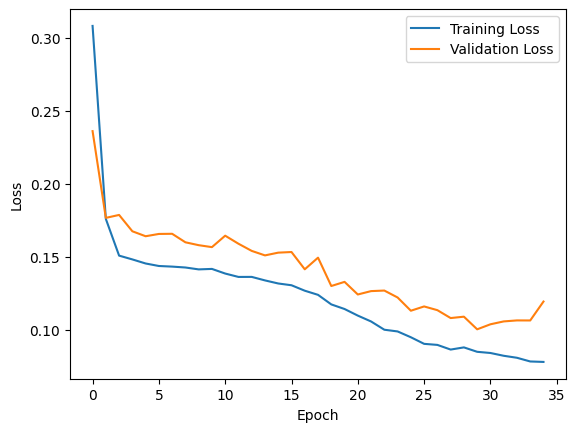

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

In [ ]:
pred = model.predict([x_test_ma, x_test_trend])
target = y_test_ma + y_test_trend
pred.shape, target.shape

14/14 [==============================] - 1s 15ms/step


((425, 7), (425, 7))

The NMAE metric for this model is much better than all of the other models we experimented with, reaching an NMAE of 0.10

In [ ]:
k_nmae_split = horizon_error_calculation(pred, target)
print(np.mean(k_nmae_split))

0.108281955


(30,) (30,)


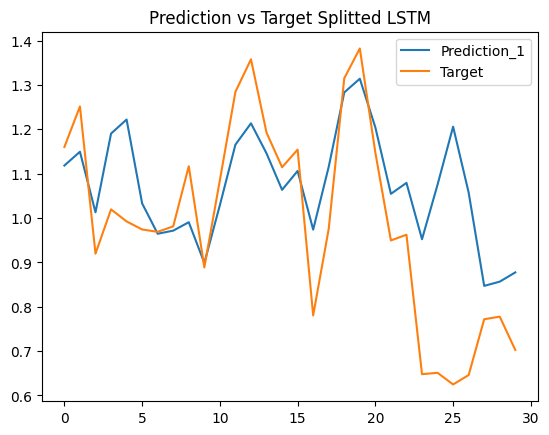

In [ ]:
prediction_horizon_1 = pred[:, 0][:30]
target_horizon_1 = target[:, 0][:30]

print(prediction_horizon_1.shape, target_horizon_1.shape)
plt.title("Prediction vs Target Splitted LSTM")
plt.plot(prediction_horizon_1, label="Prediction_1")
plt.plot(target_horizon_1, label="Target")
plt.legend()

### Cross-Validation

Having a model outperforming all the others, with the others being pretty average, we decided to perform a time series cross validation on the best model we got which was the LSTM used with the two separate signals

In [ ]:
n_splits = 5
history = best_hist

tscv = TimeSeriesSplit(n_splits=n_splits)
fold_results = []

for train_index, test_index in tscv.split(train):
    train_data, val_data = train[train_index], train[test_index]
    print(train_data.shape, val_data.shape)

    x_train, y_train = xy_to_reshape(train_data, history, pred_horizon)
    x_val, y_val = xy_to_reshape(val_data, history, pred_horizon)

    model = lstm_trainer(x_train, y_train, epochs=200, batch_size=64)

    x_val = x_val.reshape((x_val.shape[0], x_val.shape[1], 1))
    pred = model.predict(x_val)

    nmae = horizon_error_calculation(pred, y_val)
    print(nmae)

    fold_results.append(nmae)

(340,) (340,)


8/8 [==============================] - 1s 12ms/step
[0.20010455, 0.20238762, 0.20283283, 0.20804872, 0.2122502, 0.20751172, 0.21475574]
(680,) (340,)
8/8 [==============================] - 1s 12ms/step
[0.21605305, 0.21926935, 0.21950291, 0.21792138, 0.21808709, 0.22238077, 0.23205861]
(1020,) (340,)
8/8 [==============================] - 1s 12ms/step
[0.1850642, 0.19772199, 0.19400997, 0.1861762, 0.18812421, 0.18376632, 0.1873583]
(1360,) (340,)
8/8 [==============================] - 1s 12ms/step
[0.25936398, 0.27451003, 0.28063965, 0.28408885, 0.2808775, 0.28242418, 0.28958347]
(1700,) (340,)
8/8 [==============================] - 1s 17ms/step
[0.2142738, 0.23242854, 0.2259902, 0.22044969, 0.21285564, 0.21647812, 0.21875438]


In [ ]:
n_splits = 5
history = best_hist

tscv = TimeSeriesSplit(n_splits=n_splits)
fold_res_split = []

for train_index, test_index in tscv.split(ma_train):
    ma_train_data, ma_val_data = ma_train[train_index], ma_train[test_index]
    trend_train_data, trend_val_data = trend_train[train_index], trend_train[test_index]

    x_train_ma, y_train_ma = xy_to_reshape(ma_train_data, history, pred_horizon)
    x_val_ma, y_val_ma = xy_to_reshape(ma_val_data, history, pred_horizon)

    x_train_trend, y_train_trend = xy_to_reshape(trend_train_data, history, pred_horizon)
    x_val_trend, y_val_trend = xy_to_reshape(trend_val_data, history, pred_horizon)

    print(x_train_ma.shape, y_train_ma.shape, x_val_ma.shape, y_val_ma.shape)
    print(x_train_trend.shape, y_train_trend.shape, x_val_trend.shape, y_val_trend.shape)

    model = splitted_lstm_trainer(x_train_ma, x_train_trend, y_train_ma=y_train_ma, y_train_trend=y_train_trend, epochs=200, batch_size=64)

    pred = model.predict([x_val_ma, x_val_trend])

    nmae = horizon_error_calculation(pred, y_val_ma + y_val_trend)
    print(nmae)
    fold_res_split.append(nmae)

(256, 78) (256, 7) (255, 78) (255, 7)
(256, 78) (256, 7) (255, 78) (255, 7)


8/8 [==============================] - 1s 17ms/step
[0.13401276, 0.14106251, 0.15505442, 0.15523605, 0.13608694, 0.13399698, 0.1425606]
(595, 78) (595, 7) (255, 78) (255, 7)
(595, 78) (595, 7) (255, 78) (255, 7)
8/8 [==============================] - 1s 15ms/step
[0.13324018, 0.12975807, 0.13153061, 0.13615744, 0.14069322, 0.14001723, 0.13956586]
(934, 78) (934, 7) (255, 78) (255, 7)
(934, 78) (934, 7) (255, 78) (255, 7)
8/8 [==============================] - 1s 17ms/step
[0.13143747, 0.13628368, 0.1353018, 0.13759518, 0.13733763, 0.14344552, 0.14018856]
(1273, 78) (1273, 7) (255, 78) (255, 7)
(1273, 78) (1273, 7) (255, 78) (255, 7)
8/8 [==============================] - 1s 19ms/step
[0.14574799, 0.15192574, 0.15206762, 0.1558844, 0.15395647, 0.1555168, 0.1565364]
(1612, 78) (1612, 7) (255, 78) (255, 7)
(1612, 78) (1612, 7) (255, 78) (255, 7)
8/8 [==============================] - 1s 18ms/step
[0.14507553, 0.1467917, 0.14988904, 0.14810535, 0.14792065, 0.14448136, 0.15030141]


# Comparison

Text(0.5, 1.0, 'NMAE of the various methods')

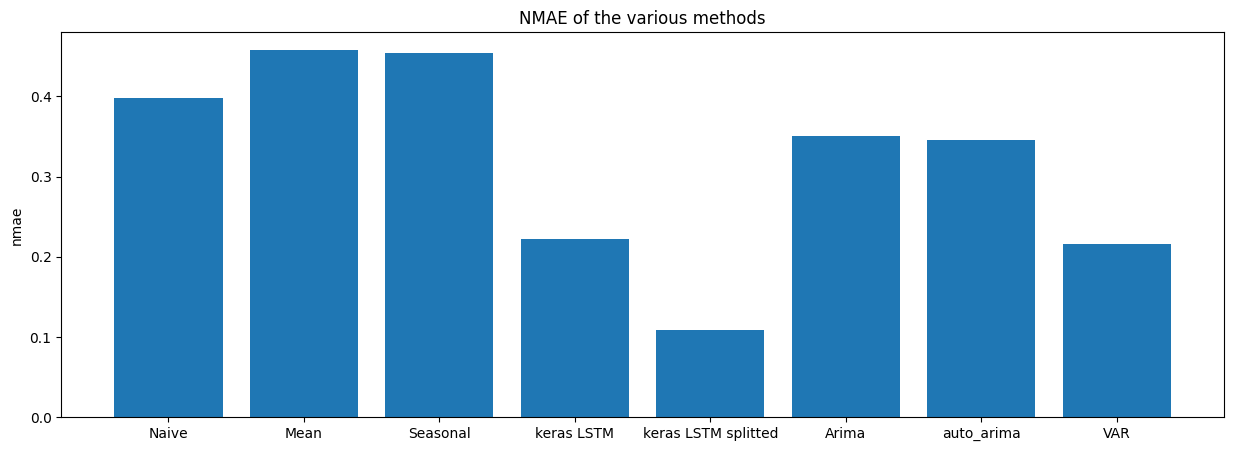

In [ ]:
plt.figure(figsize=(15, 5))
plt.bar(['Naive', 'Mean', 'Seasonal', "keras LSTM", "keras LSTM splitted", "Arima", "auto_arima","VAR" ], [np.mean(nmae_naive), np.mean(nmae_mean), np.mean(nmae_seasonal), np.mean(k_nmae), np.mean(k_nmae_split), np.mean(arima_nmae), np.mean(auto_arima_rmse), np.mean(var_nmae)])
plt.ylabel('nmae')
plt.title('NMAE of the various methods')

As we can observe from our extensive analysis, and from the plots above, there is a big difference in performance between neural networks and classic time series statistical approaches, with a big gap between the two groups. More in detail, we can also observe the superiority of the splitted LSTM model compared to the standard one.

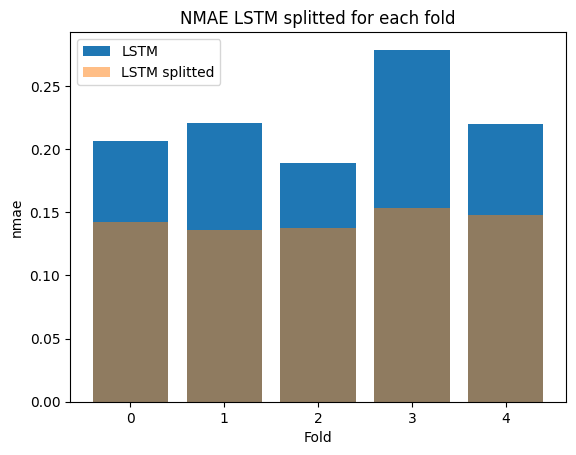

In [ ]:
plt.bar(range(5), np.mean(fold_results, axis=1), label='LSTM')
plt.bar(range(5), np.mean(fold_res_split, axis=1), label='LSTM splitted', alpha=0.5)
plt.ylabel('nmae')
plt.xlabel('Fold')
plt.title('NMAE LSTM splitted for each fold')
plt.legend()

From the latter plot we can furtherly observe the difference between the two LSTM models. In fact, the NMAE for the 5 folds is much lower in the splitted LSTM approach, outperforming its rival in each of the circumstances